# PCA v4 — Driver Performance States

**Input:** `telemetry_features_v4.parquet` (3331 filas × 26 features)  
**Output:** `telemetry_pca_v4.parquet` — PC scores por vuelta + etiqueta de estado  
**Objetivo:** Reducir 26 features de telemetría a 3-4 componentes interpretables que representen el *estado de rendimiento* del piloto en cada vuelta

| Estado esperado | Descripción |
|---|---|
| **Push Lap** | Throttle alto, RPM alto, lap_duration bajo, tyre_age bajo |
| **Energy Saving** | Throttle bajo, coasting alto, pace sacrificado |
| **Tyre Management** | lap_vs_best_stint alto, deg_rate creciendo, ritmo decayendo |
| **Pit Out / Fresh Tyre** | tyre_age = 1-2, lap_duration rápido, stint_number alto |

In [109]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

BASE_DIR = Path('../../data')
FEAT_DIR = BASE_DIR  / 'features'

print('Librerías OK')

Librerías OK


---
## 1. Carga y preparación

In [110]:
df = pl.read_parquet(FEAT_DIR / 'telemetry_features_v4.parquet')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (3331, 30)


race_name,session_key,driver_number,lap_number,lap_duration,duration_sector_1,duration_sector_2,duration_sector_3,st_speed,i1_speed,i2_speed,throttle_mean_lap,throttle_pct_full,brake_max_lap,coasting_pct,rpm_max_lap,n_gear_max_lap,tyre_age,compound_ord,lap_vs_best_stint,position,stint_number,is_pit_out_lap,is_pit_lap,speed_per_rpm,sector1_pct,sector3_pct,sector_balance,throttle_brake_ratio,best_lap_stint
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,f64,f64,f64,f64,f64,f64,f64
"""australia""",11234.0,1.0,2.0,86.863,30.541,18.252,38.07,273.0,245.0,311.0,60.924699,0.609247,104.0,0.0,12704.0,8.0,1.0,2.0,0.022182,8.0,1.0,false,0.0,0.021489,0.3516,0.438276,0.802233,0.585814,84.978
"""australia""",11234.0,1.0,3.0,85.857,30.19,18.193,37.474,276.0,249.0,304.0,63.698171,0.636982,100.0,0.0,12890.0,8.0,2.0,2.0,0.010344,10.0,1.0,false,0.0,0.021412,0.351631,0.43647,0.805625,0.636982,84.978
"""australia""",11234.0,1.0,4.0,85.573,29.93,17.868,37.775,null,260.0,297.0,58.665644,0.586656,100.0,0.0,13009.0,8.0,3.0,2.0,0.007002,7.0,1.0,false,0.0,null,0.34976,0.441436,0.792323,0.586656,84.978


In [111]:
df.shape

(3331, 30)

In [112]:
df.columns

['race_name',
 'session_key',
 'driver_number',
 'lap_number',
 'lap_duration',
 'duration_sector_1',
 'duration_sector_2',
 'duration_sector_3',
 'st_speed',
 'i1_speed',
 'i2_speed',
 'throttle_mean_lap',
 'throttle_pct_full',
 'brake_max_lap',
 'coasting_pct',
 'rpm_max_lap',
 'n_gear_max_lap',
 'tyre_age',
 'compound_ord',
 'lap_vs_best_stint',
 'position',
 'stint_number',
 'is_pit_out_lap',
 'is_pit_lap',
 'speed_per_rpm',
 'sector1_pct',
 'sector3_pct',
 'sector_balance',
 'throttle_brake_ratio',
 'best_lap_stint']

In [113]:
import requests

# ── Obtener team_name desde OpenF1 /drivers ───────────────────────────────
SESSION_KEYS = df.select('session_key').unique().to_series().to_list()

drivers_list = []
for sk in SESSION_KEYS:
    url = f'https://api.openf1.org/v1/drivers?session_key={sk}'
    r = requests.get(url)
    if r.status_code == 200:
        drivers_list.extend(r.json())

df_drivers = (
    pl.DataFrame(drivers_list)
      .select(['session_key', 'driver_number', 'team_name', 'name_acronym'])
      .unique(subset=['session_key', 'driver_number'])
      .with_columns([
          pl.col('session_key').cast(pl.Float64),    # ← match con df_master
          pl.col('driver_number').cast(pl.Float64),  # ← por si acaso
      ])
)

# Join al df_master
df = df.join(df_drivers, on=['session_key', 'driver_number'], how='left')

print(df.select(['driver_number', 'team_name', 'name_acronym']).unique().sort('team_name'))

shape: (22, 3)
┌───────────────┬─────────────────┬──────────────┐
│ driver_number ┆ team_name       ┆ name_acronym │
│ ---           ┆ ---             ┆ ---          │
│ f64           ┆ str             ┆ str          │
╞═══════════════╪═════════════════╪══════════════╡
│ 10.0          ┆ Alpine          ┆ GAS          │
│ 43.0          ┆ Alpine          ┆ COL          │
│ 14.0          ┆ Aston Martin    ┆ ALO          │
│ 18.0          ┆ Aston Martin    ┆ STR          │
│ 5.0           ┆ Audi            ┆ BOR          │
│ …             ┆ …               ┆ …            │
│ 30.0          ┆ Racing Bulls    ┆ LAW          │
│ 3.0           ┆ Red Bull Racing ┆ VER          │
│ 6.0           ┆ Red Bull Racing ┆ HAD          │
│ 23.0          ┆ Williams        ┆ ALB          │
│ 55.0          ┆ Williams        ┆ SAI          │
└───────────────┴─────────────────┴──────────────┘


In [114]:
# ── Separar identificadores de features ───────────────────────────────────
ID_COLS = ['race_name', 'driver_number', 'lap_number', 'team_name']

# Columnas que NO entran al PCA (binarias de estado, no de rendimiento)
EXCLUDE = ['is_pit_out_lap', 'is_pit_lap', 'stint_number']

feature_cols = [
    c for c in df.columns
    if c not in ID_COLS + EXCLUDE
]

df_pd = df.to_pandas()
# ── Filtros (pit laps + anomalías) ─────────────────────────────────────────
df_pd = df_pd[
    (df_pd['is_pit_lap'] != 1) &
    (df_pd['is_pit_out_lap'] != 1)
].reset_index(drop=True)

lap_median = df_pd.groupby('race_name')['lap_duration'].transform('median')
lap_std    = df_pd.groupby('race_name')['lap_duration'].transform('std')
df_pd = df_pd[
    df_pd['lap_duration'] <= lap_median + 2 * lap_std
].reset_index(drop=True)

print(f'Filas finales: {len(df_pd)}')
print(f'team_name present: {"team_name" in df_pd.columns}')
X_raw = df_pd[feature_cols]

print(f'Features que entran al PCA: {len(feature_cols)}')
print(feature_cols)

Filas finales: 3004
team_name present: True
Features que entran al PCA: 25
['session_key', 'lap_duration', 'duration_sector_1', 'duration_sector_2', 'duration_sector_3', 'st_speed', 'i1_speed', 'i2_speed', 'throttle_mean_lap', 'throttle_pct_full', 'brake_max_lap', 'coasting_pct', 'rpm_max_lap', 'n_gear_max_lap', 'tyre_age', 'compound_ord', 'lap_vs_best_stint', 'position', 'speed_per_rpm', 'sector1_pct', 'sector3_pct', 'sector_balance', 'throttle_brake_ratio', 'best_lap_stint', 'name_acronym']


In [115]:
X_raw.columns

Index(['session_key', 'lap_duration', 'duration_sector_1', 'duration_sector_2',
       'duration_sector_3', 'st_speed', 'i1_speed', 'i2_speed',
       'throttle_mean_lap', 'throttle_pct_full', 'brake_max_lap',
       'coasting_pct', 'rpm_max_lap', 'n_gear_max_lap', 'tyre_age',
       'compound_ord', 'lap_vs_best_stint', 'position', 'speed_per_rpm',
       'sector1_pct', 'sector3_pct', 'sector_balance', 'throttle_brake_ratio',
       'best_lap_stint', 'name_acronym'],
      dtype='object')

In [116]:
# ── Diagnóstico de nulos ───────────────────────────────────────────────────
null_pct = X_raw.isnull().mean().sort_values(ascending=False)
print('Nulos por feature:')
print(null_pct[null_pct > 0].to_string())

# Eliminar columnas con > 40% nulos
cols_ok = null_pct[null_pct <= 0.4].index.tolist()
cols_dropped = null_pct[null_pct > 0.4].index.tolist()

if cols_dropped:
    print(f'\nEliminadas (> 40% nulos): {cols_dropped}')
else:
    print('\nNinguna columna eliminada por nulos')

X = X_raw[cols_ok].copy()
print(f'\nFeatures finales para PCA: {X.shape[1]}')

Nulos por feature:
speed_per_rpm           0.388815
brake_max_lap           0.384820
rpm_max_lap             0.384820
n_gear_max_lap          0.384820
throttle_brake_ratio    0.384820
throttle_pct_full       0.384820
throttle_mean_lap       0.384820
compound_ord            0.299268
i1_speed                0.168442
st_speed                0.021638
duration_sector_1       0.004660
sector1_pct             0.004660
sector_balance          0.004660

Ninguna columna eliminada por nulos

Features finales para PCA: 25


In [117]:
# ── Eliminar columnas no numéricas que se hayan colado ────────────────────
X = X.select_dtypes(include='number')
print(f'Columnas numéricas para PCA: {X.shape[1]}')
print(f'Columnas eliminadas: {[c for c in cols_ok if c not in X.columns]}')

Columnas numéricas para PCA: 24
Columnas eliminadas: ['name_acronym']


In [118]:
# ── Imputación y escalado ──────────────────────────────────────────────────
# Imputar con mediana (robusto a outliers de safety car / pit laps)
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X)

# Escalar: obligatorio antes de PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

print(f'Matrix lista para PCA: {X_scaled.shape}')

Matrix lista para PCA: (3004, 24)


---
## 2. PCA — Varianza explicada

In [119]:
# ── PCA completo para ver el scree plot ───────────────────────────────────
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

var_ind  = pca_full.explained_variance_ratio_
var_cum  = np.cumsum(var_ind)
n_pcs    = len(var_ind)

# Umbral: cuántos PCs para 80% y 90%
n_80 = next(i+1 for i, v in enumerate(var_cum) if v >= 0.80)
n_90 = next(i+1 for i, v in enumerate(var_cum) if v >= 0.90)

print('Varianza explicada acumulada:')
for i, v in enumerate(var_cum[:10]):
    marker = ' ← 80%' if i+1 == n_80 else (' ← 90%' if i+1 == n_90 else '')
    print(f'  PC{i+1:2d}: {var_ind[i]:.1%} individual  |  {v:.1%} acumulada{marker}')

print(f'\n→ {n_80} PCs explican el 80% de la varianza')
print(f'→ {n_90} PCs explican el 90% de la varianza')

Varianza explicada acumulada:
  PC 1: 25.1% individual  |  25.1% acumulada
  PC 2: 16.0% individual  |  41.1% acumulada
  PC 3: 13.4% individual  |  54.5% acumulada
  PC 4: 9.8% individual  |  64.3% acumulada
  PC 5: 8.4% individual  |  72.7% acumulada
  PC 6: 6.0% individual  |  78.7% acumulada
  PC 7: 5.1% individual  |  83.8% acumulada ← 80%
  PC 8: 3.7% individual  |  87.5% acumulada
  PC 9: 3.2% individual  |  90.7% acumulada ← 90%
  PC10: 2.9% individual  |  93.6% acumulada

→ 7 PCs explican el 80% de la varianza
→ 9 PCs explican el 90% de la varianza


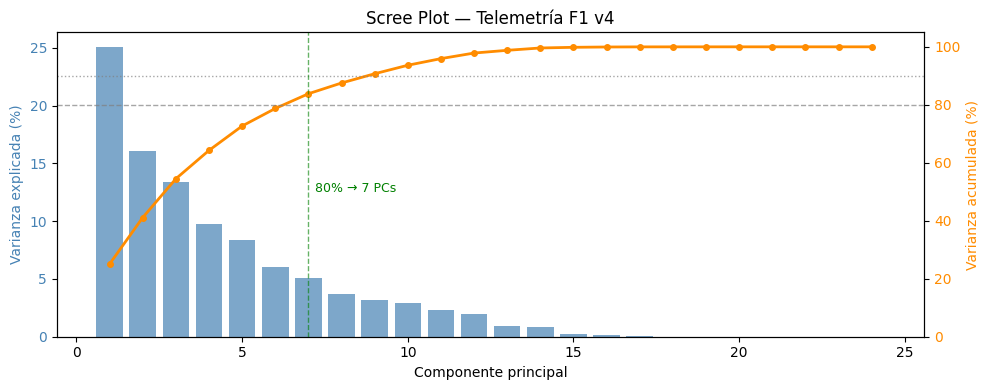

Scree plot guardado


In [120]:
# ── Scree plot ─────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 4))

x = np.arange(1, n_pcs + 1)
ax1.bar(x, var_ind * 100, color='steelblue', alpha=0.7, label='Varianza individual')
ax1.set_xlabel('Componente principal')
ax1.set_ylabel('Varianza explicada (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(x, var_cum * 100, color='darkorange', marker='o', markersize=4, linewidth=2, label='Varianza acumulada')
ax2.axhline(80, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax2.axhline(90, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax2.axvline(n_80, color='green', linestyle='--', linewidth=1, alpha=0.6)
ax2.text(n_80 + 0.2, 50, f'80% → {n_80} PCs', color='green', fontsize=9)
ax2.set_ylabel('Varianza acumulada (%)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.set_ylim(0, 105)

plt.title('Scree Plot — Telemetría F1 v4')
fig.tight_layout()
plt.savefig(FEAT_DIR / 'scree_plot_v4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Scree plot guardado')

---
## 3. PCA final con N componentes seleccionados

In [121]:
# Usar los PCs que explican el 80% (decisión conservadora para telemetría)
# Si n_80 > 6, forzamos 6 para mantener interpretabilidad
N_COMPONENTS = min(n_80, 6)
print(f'Componentes seleccionados: {N_COMPONENTS}')

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Varianza explicada con {N_COMPONENTS} PCs: {pca.explained_variance_ratio_.sum():.1%}')

Componentes seleccionados: 6
Varianza explicada con 6 PCs: 78.7%


---
## 4. Interpretación de loadings

In [122]:
# ── Tabla de loadings ──────────────────────────────────────────────────────
# ✅ Usar las columnas reales de X, no cols_ok
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,  # ← en lugar de cols_ok
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)

print('Top 5 variables por componente (por valor absoluto):')
print('=' * 60)
for pc in loadings.columns:
    top = loadings[pc].abs().sort_values(ascending=False).head(5)
    print(f'\n{pc} ({pca.explained_variance_ratio_[int(pc[2:])-1]:.1%}):')
    for var, val in top.items():
        sign = '+' if loadings.loc[var, pc] > 0 else '−'
        print(f'  {sign}{val:.3f}  {var}')

Top 5 variables por componente (por valor absoluto):

PC1 (25.1%):
  +0.398  sector3_pct
  +0.372  duration_sector_3
  −0.371  sector_balance
  −0.357  duration_sector_2
  −0.354  duration_sector_1

PC2 (16.0%):
  +0.372  throttle_brake_ratio
  +0.370  throttle_pct_full
  +0.370  throttle_mean_lap
  +0.359  i2_speed
  +0.255  sector1_pct

PC3 (13.4%):
  +0.410  best_lap_stint
  +0.313  st_speed
  +0.311  brake_max_lap
  −0.307  sector1_pct
  +0.295  throttle_mean_lap

PC4 (9.8%):
  +0.473  lap_vs_best_stint
  +0.449  lap_duration
  −0.319  st_speed
  −0.252  speed_per_rpm
  +0.227  brake_max_lap

PC5 (8.4%):
  +0.385  i2_speed
  +0.375  i1_speed
  +0.341  compound_ord
  −0.311  position
  −0.286  throttle_brake_ratio

PC6 (6.0%):
  +0.629  rpm_max_lap
  −0.496  speed_per_rpm
  −0.282  n_gear_max_lap
  −0.273  lap_vs_best_stint
  +0.243  brake_max_lap


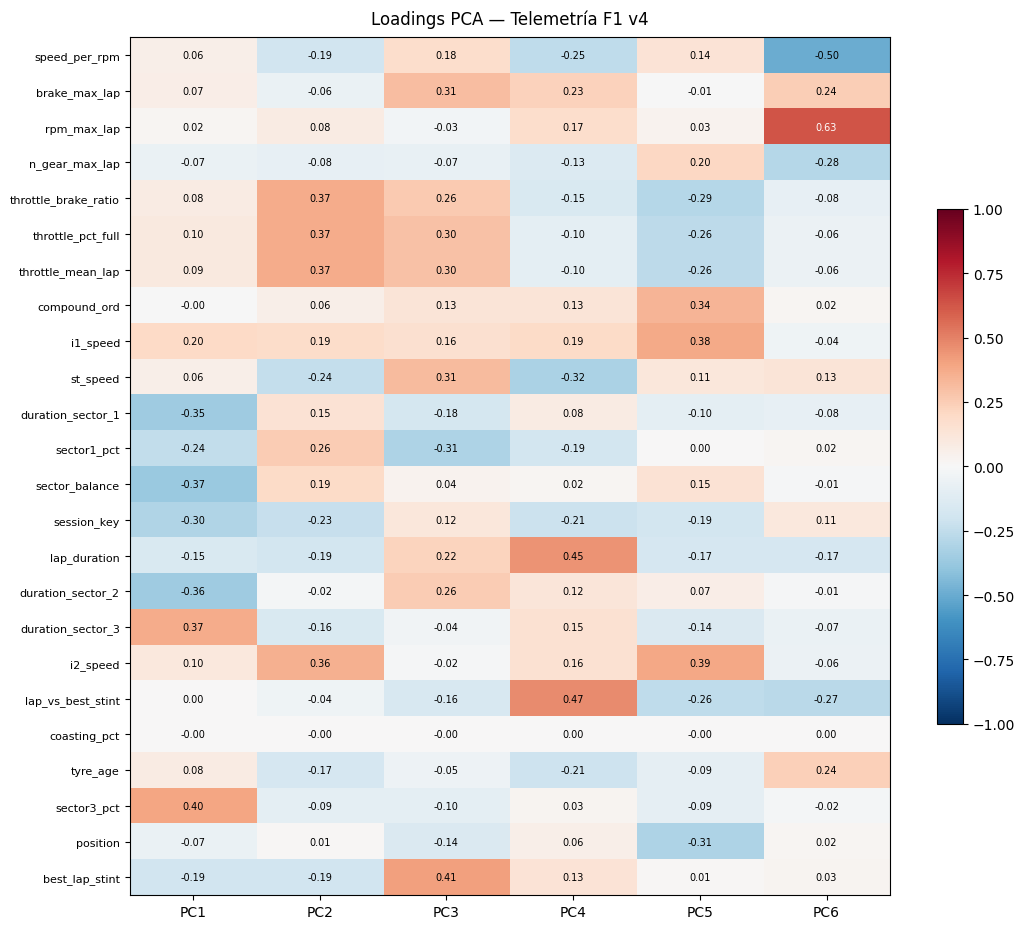

Heatmap guardado


In [123]:
# ── Heatmap de loadings ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(N_COMPONENTS * 1.5 + 2, len(X.columns) * 0.35 + 1))

im = ax.imshow(loadings.values, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.6)

ax.set_xticks(range(N_COMPONENTS))
ax.set_xticklabels(loadings.columns, fontsize=10)
ax.set_yticks(range(len(X.columns)))
ax.set_yticklabels(X.columns, fontsize=8)

for i in range(len(X.columns)):
    for j in range(N_COMPONENTS):
        val = loadings.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7, color='black' if abs(val) < 0.6 else 'white')
ax.set_title('Loadings PCA — Telemetría F1 v4', fontsize=12, pad=10)
plt.tight_layout()
plt.savefig(FEAT_DIR / 'loadings_heatmap_v4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap guardado')

In [124]:
# ── Interpretación manual de cada PC ──────────────────────────────────────
# Este bloque imprime un diagnóstico automático basado en los loadings
# para ayudarte a etiquetar cada componente

POSITIVE_LABELS = {
    'lap_duration'         : 'vuelta lenta',
    'duration_sector_1'    : 'S1 lento',
    'duration_sector_2'    : 'S2 lento',
    'duration_sector_3'    : 'S3 lento',
    'tyre_age'             : 'neumático viejo',
    'lap_vs_best_stint'    : 'degradación alta',
    'brake_max_lap'        : 'frenada fuerte',
    'coasting_pct'         : 'coasting alto',
    'compound_ord'         : 'compuesto duro',
    'st_speed'             : 'velocidad punta alta',
    'i1_speed'             : 'velocidad I1 alta',
    'i2_speed'             : 'velocidad I2 alta',
    'throttle_mean_lap'    : 'throttle alto',
    'throttle_pct_full'    : 'máximo throttle frecuente',
    'rpm_max_lap'          : 'RPM alto',
    'n_gear_max_lap'       : 'marcha alta',
    'speed_per_rpm'        : 'eficiencia motor alta',
    'sector1_pct'          : 'S1 pesa más en vuelta',
    'sector3_pct'          : 'S3 pesa más en vuelta',
    'sector_balance'       : 'desequilibrio S1/S3',
    'throttle_brake_ratio' : 'más gas que freno',
    'best_lap_stint'       : 'mejor vuelta del stint lenta',
    'position'             : 'posición trasera',
    'gap_to_leader'        : 'lejos del líder',
}

print('INTERPRETACIÓN AUTOMÁTICA DE COMPONENTES')
print('=' * 60)
for pc in loadings.columns:
    top_pos = loadings[pc].nlargest(3)
    top_neg = loadings[pc].nsmallest(3)
    print(f'\n{pc}:')
    print('  Polo + (loading positivo):')
    for var, val in top_pos.items():
        print(f'    +{val:.3f} {var} → {POSITIVE_LABELS.get(var, var)}')
    print('  Polo − (loading negativo):')
    for var, val in top_neg.items():
        print(f'    {val:.3f} {var} → inverso de: {POSITIVE_LABELS.get(var, var)}')

INTERPRETACIÓN AUTOMÁTICA DE COMPONENTES

PC1:
  Polo + (loading positivo):
    +0.398 sector3_pct → S3 pesa más en vuelta
    +0.372 duration_sector_3 → S3 lento
    +0.197 i1_speed → velocidad I1 alta
  Polo − (loading negativo):
    -0.371 sector_balance → inverso de: desequilibrio S1/S3
    -0.357 duration_sector_2 → inverso de: S2 lento
    -0.354 duration_sector_1 → inverso de: S1 lento

PC2:
  Polo + (loading positivo):
    +0.372 throttle_brake_ratio → más gas que freno
    +0.370 throttle_pct_full → máximo throttle frecuente
    +0.370 throttle_mean_lap → throttle alto
  Polo − (loading negativo):
    -0.239 st_speed → inverso de: velocidad punta alta
    -0.227 session_key → inverso de: session_key
    -0.194 best_lap_stint → inverso de: mejor vuelta del stint lenta

PC3:
  Polo + (loading positivo):
    +0.410 best_lap_stint → mejor vuelta del stint lenta
    +0.313 st_speed → velocidad punta alta
    +0.311 brake_max_lap → frenada fuerte
  Polo − (loading negativo):
    -0.

---
## 5. Scatter PC1 vs PC2 por carrera

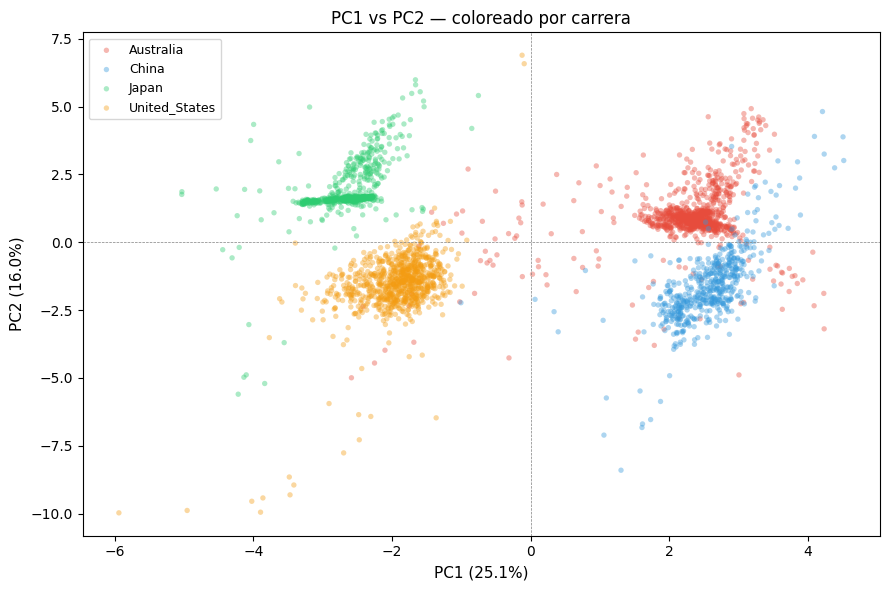

In [125]:
# ── Scatter coloreado por carrera ──────────────────────────────────────────
races   = df_pd['race_name'].values
unique  = sorted(set(races))
palette = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']
color_map = {r: palette[i] for i, r in enumerate(unique)}

fig, ax = plt.subplots(figsize=(9, 6))
for race in unique:
    mask = races == race
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=color_map[race], label=race.replace('_2026','').title(),
        alpha=0.4, s=15, edgecolors='none'
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax.set_title('PC1 vs PC2 — coloreado por carrera', fontsize=12)
ax.legend(fontsize=9)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.savefig(FEAT_DIR / 'scatter_pc1_pc2_race_v4.png', dpi=150, bbox_inches='tight')
plt.show()

# Si los puntos se separan por carrera → PC1/PC2 capturan contexto, no estilo puro
# Si hay mezcla → los PCs capturan genuinamente estados de conducción

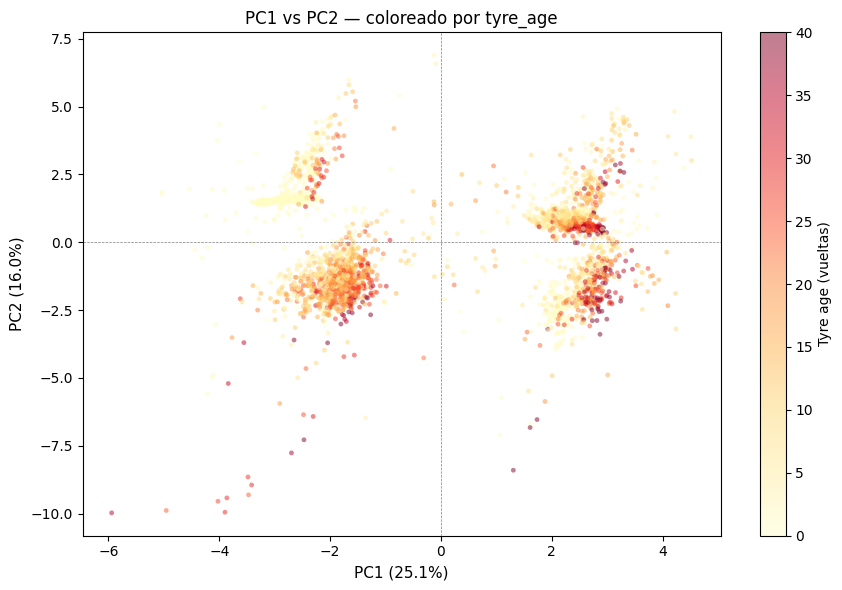

In [127]:
# ── Scatter coloreado por tyre_age (proxy de estado del neumático) ─────────
tyre_age = df_pd['tyre_age'].fillna(0).values

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=tyre_age, cmap='YlOrRd', alpha=0.5, s=12,
    vmin=0, vmax=40, edgecolors='none'
)
plt.colorbar(sc, ax=ax, label='Tyre age (vueltas)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax.set_title('PC1 vs PC2 — coloreado por tyre_age', fontsize=12)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.savefig(FEAT_DIR / 'scatter_pc1_pc2_tyreage_v4.png', dpi=150, bbox_inches='tight')
plt.show()

# Si hay gradiente de color ordenado → PC1 o PC2 captura degradación de neumático

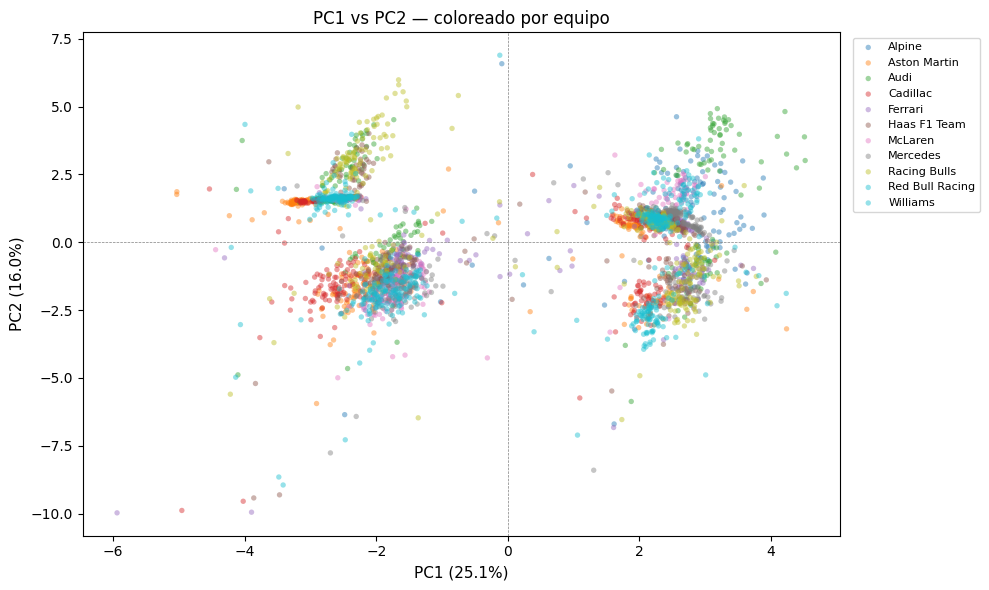

In [128]:
# ── Scatter coloreado por equipo ───────────────────────────────────────────
# ✅ Después
teams = df_pd.loc[X.index, 'team_name'].fillna('Unknown').values
unique_t = sorted(set(teams))
palette_t = plt.cm.tab10(np.linspace(0, 1, len(unique_t)))
cmap_t   = {t: palette_t[i] for i, t in enumerate(unique_t)}

fig, ax = plt.subplots(figsize=(10, 6))
for team in unique_t:
    mask = teams == team
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=[cmap_t[team]], label=team,
        alpha=0.45, s=15, edgecolors='none'
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax.set_title('PC1 vs PC2 — coloreado por equipo', fontsize=12)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.savefig(FEAT_DIR / 'scatter_pc1_pc2_team_v4.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Exportación de PC scores

In [129]:
# ── Construir df con scores + identificadores ──────────────────────────────
pc_cols = [f'PC{i+1}' for i in range(N_COMPONENTS)]

df_scores = df_pd[ID_COLS + ['tyre_age', 'is_pit_out_lap', 'is_pit_lap', 'stint_number']].copy()
for i, col in enumerate(pc_cols):
    df_scores[col] = X_pca[:, i]

print(f'Shape df_scores: {df_scores.shape}')
df_scores.head(5)

Shape df_scores: (3004, 14)


,race_name,driver_number,lap_number,team_name,tyre_age,is_pit_out_lap,is_pit_lap,stint_number,PC1,PC2,PC3,PC4,PC5,PC6
0,australia,1.0,2.0,McLaren,1.0,False,0.0,1.0,1.955763,1.173449,-2.350379,1.602183,-0.091803,2.768580
1,australia,1.0,3.0,McLaren,2.0,False,0.0,1.0,2.023648,2.126923,-2.502114,0.777434,-0.612670,2.805217
2,australia,1.0,4.0,McLaren,3.0,False,0.0,1.0,2.241707,0.278665,-2.275132,0.059945,1.032301,1.920879
3,australia,1.0,5.0,McLaren,4.0,False,0.0,1.0,2.006631,1.736223,-3.006529,1.042217,0.235334,3.480459
4,australia,1.0,6.0,McLaren,5.0,False,0.0,1.0,2.186623,1.437098,-2.134412,-0.254337,0.168087,0.896240


In [132]:
# ── Agregar PC scores por evento táctico ───────────────────────────────────
# Para cada evento en df_events, calcular mean/std de los PC scores
# de las 3 vueltas previas del atacante y del defensor
# Esto es el PUENTE entre la capa de telemetría y el clustering táctico

df_tact = pl.read_parquet(FEAT_DIR / 'tactical_features_v4.parquet').to_pandas()

def aggregate_pc_scores(event_row, df_scores, driver_col, prefix, window=3):
    """Agrega PC scores de las últimas `window` vueltas de un piloto antes del evento."""
    race = event_row['race_name']
    lap  = int(event_row['lap_number'])
    drv  = event_row[driver_col]
    target_laps = list(range(lap - window, lap))

    sub = df_scores[
        (df_scores['race_name'] == race) &
        (df_scores['driver_number'] == drv) &
        (df_scores['lap_number'].isin(target_laps))
    ]

    result = {}
    for pc in pc_cols:
        result[f'{prefix}_{pc}_mean'] = sub[pc].mean() if not sub.empty else None
        result[f'{prefix}_{pc}_std']  = sub[pc].std()  if not sub.empty else None
    return result


print('Agregando PC scores por evento...')
pc_agg_list = []
for _, row in df_tact.iterrows():
    att_pcs = aggregate_pc_scores(row, df_scores, 'attacker', 'att')
    def_pcs = aggregate_pc_scores(row, df_scores, 'defender', 'def')

    # Delta entre atacante y defensor para cada PC
    deltas = {}
    for pc in pc_cols:
        a = att_pcs.get(f'att_{pc}_mean')
        d = def_pcs.get(f'def_{pc}_mean')
        deltas[f'delta_{pc}_mean'] = a - d if a is not None and d is not None else None

    pc_agg_list.append({**att_pcs, **def_pcs, **deltas})

df_pc_agg = pd.DataFrame(pc_agg_list)
df_tact_enriched = pd.concat([df_tact.reset_index(drop=True), df_pc_agg], axis=1)

print(f'Features tácticas enriquecidas: {df_tact_enriched.shape}')
print(f'Columnas nuevas de PC scores: {df_pc_agg.columns.tolist()}')

Agregando PC scores por evento...
Features tácticas enriquecidas: (643, 62)
Columnas nuevas de PC scores: ['att_PC1_mean', 'att_PC1_std', 'att_PC2_mean', 'att_PC2_std', 'att_PC3_mean', 'att_PC3_std', 'att_PC4_mean', 'att_PC4_std', 'att_PC5_mean', 'att_PC5_std', 'att_PC6_mean', 'att_PC6_std', 'def_PC1_mean', 'def_PC1_std', 'def_PC2_mean', 'def_PC2_std', 'def_PC3_mean', 'def_PC3_std', 'def_PC4_mean', 'def_PC4_std', 'def_PC5_mean', 'def_PC5_std', 'def_PC6_mean', 'def_PC6_std', 'delta_PC1_mean', 'delta_PC2_mean', 'delta_PC3_mean', 'delta_PC4_mean', 'delta_PC5_mean', 'delta_PC6_mean']


In [133]:
# ── Guardar todo ───────────────────────────────────────────────────────────

# 1. PC scores por vuelta (para análisis y visualización)
out_scores = FEAT_DIR / 'telemetry_pca_v4.parquet'
pl.from_pandas(df_scores).write_parquet(str(out_scores))
print(f'Scores guardados: {out_scores}  {df_scores.shape}')

# 2. Features tácticas enriquecidas con PC scores (INPUT para clustering)
out_enriched = FEAT_DIR / 'tactical_enriched_v4.parquet'
pl.from_pandas(df_tact_enriched).write_parquet(str(out_enriched))
print(f'Tácticas enriquecidas: {out_enriched}  {df_tact_enriched.shape}')

# 3. Objeto PCA + scaler para reutilizar
import joblib
joblib.dump(pca,    FEAT_DIR / 'pca_model_v4.pkl')
joblib.dump(scaler, FEAT_DIR / 'scaler_v4.pkl')
joblib.dump(imputer,FEAT_DIR / 'imputer_v4.pkl')
print('Modelos guardados (.pkl)')

print(f'\n✅ PCA completado')
print(f'   Componentes : {N_COMPONENTS}')
print(f'   Varianza    : {pca.explained_variance_ratio_.sum():.1%}')
print(f'\nSiguiente paso → Clustering sobre tactical_enriched_v4.parquet')

Scores guardados: ..\..\data\features\telemetry_pca_v4.parquet  (3004, 14)
Tácticas enriquecidas: ..\..\data\features\tactical_enriched_v4.parquet  (643, 62)
Modelos guardados (.pkl)

✅ PCA completado
   Componentes : 6
   Varianza    : 78.7%

Siguiente paso → Clustering sobre tactical_enriched_v4.parquet
